
**La'China Barnes - EDA**

Exploring the Effects of Pollutants on Asthma ER Visits across NYC

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [ ]:
df=pd.read_csv("../data/air_quality_data.csv")
df.shape

(18862, 15)

In [3]:
df.head()

,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,start_date,data_value,:id,:version,:created_at,:updated_at
0,874416,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF34,102,Northeast Bronx,Summer 2023,2023-06-01T00:00:00.000,9.237951,row-n34f~sr35~bfnv,rv-tnts_m7uf_d99g,2025-03-24T19:25:36.580Z,2026-03-16T14:19:15.028Z
1,877080,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,501502,Northern SI,Summer 2023,2023-06-01T00:00:00.000,12.522830,row-dkmy-tbgy-bqgv,rv-hx3s_s9fb.k8t9,2025-03-24T19:25:36.580Z,2026-03-16T14:19:15.028Z
2,876849,375,Nitrogen dioxide (NO2),Mean,ppb,Borough,2,Brooklyn,Summer 2023,2023-06-01T00:00:00.000,12.522216,row-ykym.d2j6.cjxj,rv-r9ae_3py2.q5yq,2025-03-24T19:25:36.580Z,2026-03-16T14:19:15.028Z
3,874599,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,204,Highbridge and Concourse (CD4),Summer 2023,2023-06-01T00:00:00.000,9.288254,row-jhbp_qhj8.9ebx,rv-62y3_jg9x~sgd6,2025-03-24T19:25:36.580Z,2026-03-16T14:19:15.028Z
4,877221,375,Nitrogen dioxide (NO2),Mean,ppb,CD,402,Woodside and Sunnyside (CD2),Summer 2023,2023-06-01T00:00:00.000,16.031326,row-zamm~r8n6-evs6,rv-gsmi_ve7r_ken2,2025-03-24T19:25:36.580Z,2026-03-16T14:19:15.028Z


**Step 1: Data Collection** 

*By leveraging the NYC Open Data API, we can evaluate the relationship between specific pollutants and asthma incidence across NYC neighborhoods. We’ll start by reviewing the dataset’s columns and then examine the DataFrame’s descriptive statistics.*


In [ ]:
df.columns.tolist() # df.column gives you an Index object containing all column names.  # .tolist() converts that Index into a regular Python list.

['unique_id',
 'indicator_id',
 'name',
 'measure',
 'measure_info',
 'geo_type_name',
 'geo_join_id',
 'geo_place_name',
 'time_period',
 'start_date',
 'data_value',
 ':id',
 ':version',
 ':created_at',
 ':updated_at']

*For a more readable print.*

In [6]:
for col in df.columns:
    print(col)

unique_id
indicator_id
name
measure
measure_info
geo_type_name
geo_join_id
geo_place_name
time_period
start_date
data_value
:id
:version
:created_at
:updated_at


In [5]:
df.describe()

,unique_id,indicator_id,geo_join_id,data_value
count,18862.000000,18862.000000,1.886200e+04,18862.000000
mean,452004.167533,431.817888,5.983262e+05,21.051580
std,262910.731230,113.946565,7.819721e+06,23.564920
min,130355.000000,365.000000,1.000000e+00,0.000000
25%,176073.250000,365.000000,2.020000e+02,8.742004
50%,412490.500000,375.000000,3.030000e+02,14.790000
75%,669588.750000,386.000000,4.040000e+02,26.267500
max,878254.000000,661.000000,1.051061e+08,424.700000


**Step 2: Univariate Analysis**

*Let’s explore how often each indicator type appears in the dataset. This helps us see which health measures are most represented before moving into deeper analysis.*

In [7]:
df['name'].value_counts()

name
Fine particles (PM 2.5)                                   6345
Nitrogen dioxide (NO2)                                    6345
Ozone (O3)                                                2115
Asthma emergency department visits due to PM2.5            480
Asthma emergency departments visits due to Ozone           480
Asthma hospitalizations due to Ozone                       480
Annual vehicle miles traveled (cars)                       321
Annual vehicle miles traveled                              321
Annual vehicle miles traveled (trucks)                     321
Deaths due to PM2.5                                        240
Cardiac and respiratory deaths due to Ozone                240
Cardiovascular hospitalizations due to PM2.5 (age 40+)     240
Respiratory hospitalizations due to PM2.5 (age 20+)        240
Outdoor Air Toxics - Formaldehyde                          203
Outdoor Air Toxics - Benzene                               203
Boiler Emissions- Total NOx Emissions             

*This visualization shows how often each indicator type appears in the dataset, helping us see which health measures are most represented*

C:\Users\lachi\AppData\Local\Temp\ipykernel_27196\286742474.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


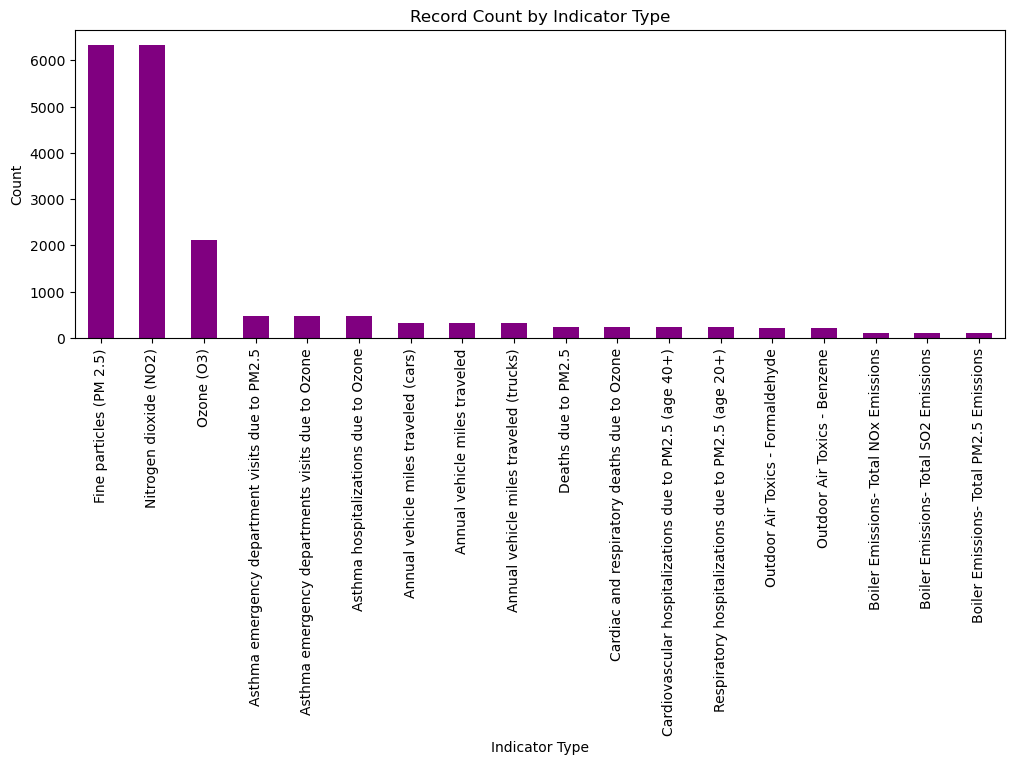

In [8]:
df['name'].value_counts().plot(kind='bar', figsize=(12,4), color='purple')
plt.title('Record Count by Indicator Type')
plt.xlabel('Indicator Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Step 3: Bivariate Analysis**

*Let’s explore how these environmental and health indicators vary across NYC neighborhoods using a heatmap. This visualiztaion helps us quickly spot which areas experience higher pollution levels and related health impacts before moving into deeper analysis.*

In [ ]:
df['name'].nunique(), df['geo_place_name'].nunique() # to confirm to see if there is enough data (indicator types and neighnorhoods) to create a heatmap. 

(18, 114)

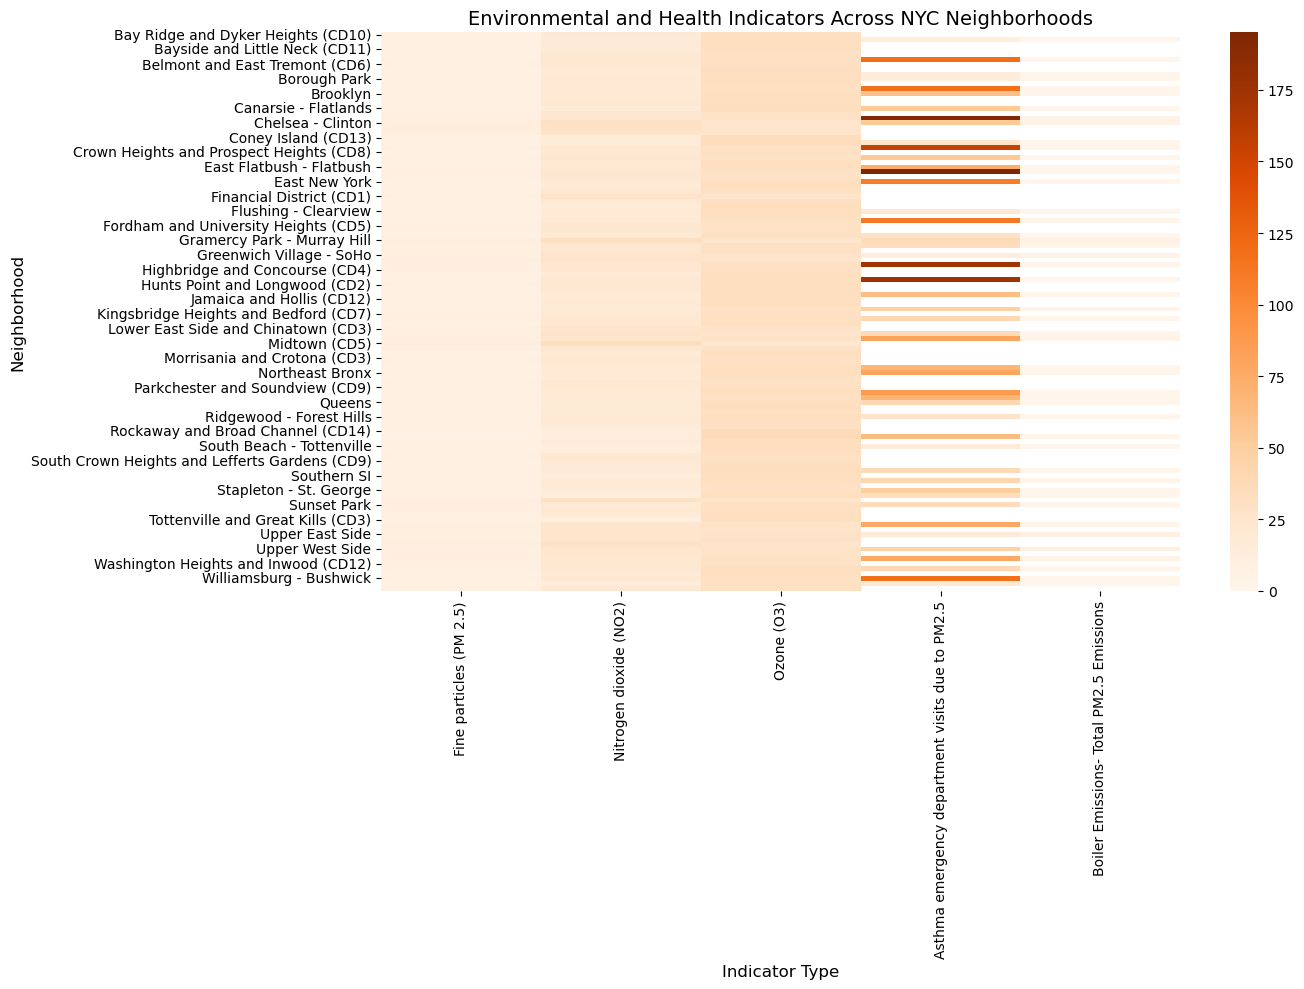

In [23]:
plt.figure(figsize=(14,10))

sns.heatmap(
    subset,
    cmap='Oranges')

plt.title('Environmental and Health Indicators Across NYC Neighborhoods', fontsize=14)
plt.xlabel('Indicator Type', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)

plt.tight_layout()
plt.show()

**Oberservations/ Findings:**

*1.Some NYC neighborhoods have more pollution than others, showing that environmental conditions aren’t the same across the city.

2.Places with higher pollution also tend to have more asthma ER visits, suggesting a connection between air quality and health.

3.Looking at multiple indicators together gives a clearer picture, helping us see which neighborhoods face several environmental and health challenges at the same time.*